# Test

In [ ]:
from core.scenario import load_scenario, run_scenario
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load and inspect a scenario

In [2]:
scenario = load_scenario("scenarios/iso20414_corridor.zip")
print(scenario.summary())

Scenario: /Users/elif/Desktop/HiWi/jupedsim-web-community/scripts/scenarios/iso20414_corridor.zip
  Model:         CollisionFreeSpeedModel
  Seed:          420
  Max time:      300s
  Exits:         1
  Distributions: 1
  Stages:        0
  Zones:         0
  Journeys:      1
  Agents:        ~60
  Journey elems: 2
  Route:         1 distribution, 0 checkpoint, 1 exit
  Sequence:      jps-distributions_0 -> jps-exits_0
    jps-distributions_0: 60 agents


## 2. Run the simulation

In [3]:
result = run_scenario(scenario)

print(f"Success:          {result.success}")
print(f"Evacuation time:  {result.evacuation_time:.2f}s")
print(f"Total agents:     {result.total_agents}")
print(f"Evacuated:        {result.agents_evacuated}")
print(f"Remaining:        {result.agents_remaining}")

dt = 1/result.frame_rate #0.1 timestep 


DEBUG: Distribution jps-distributions_0 RAW params from JSON: {'number': 60, 'radius': 0.2, 'v0': 1, 'distribution_mode': 'by_number', 'percentage': None, 'use_flow_spawning': False, 'flow_start_time': 0, 'flow_end_time': 10, 'use_premovement': False, 'premovement_distribution': 'gamma', 'premovement_param_a': None, 'premovement_param_b': None, 'premovement_seed': None, 'radius_distribution': 'constant', 'v0_distribution': 'constant'}
DEBUG: Distribution jps-distributions_0 processed params: {'number': 60, 'radius': 0.2, 'v0': 1, 'use_flow_spawning': False, 'flow_start_time': 0, 'flow_end_time': 10, 'use_premovement': False, 'premovement_distribution': 'gamma', 'premovement_param_a': None, 'premovement_param_b': None, 'premovement_seed': None, 'radius_distribution': 'constant', 'radius_std': None, 'v0_distribution': 'constant', 'v0_std': None, 'distribution_mode': 'by_number', 'percentage': None}
Creating journeys with routing: {}
Processing journey journey_0 with stages: ['jps-distrib

## 3. Analyze trajectory data

In [4]:
df = result.trajectory_dataframe()
print(f"Trajectory: {len(df)} rows, {df['id'].nunique()} agents, {df['frame'].nunique()} frames")
df["time"] = df["frame"]*dt
df.tail(10)

Trajectory: 18046 rows, 60 agents, 595 frames


,frame,id,x,y,ori_x,ori_y,time
18036,585,49,28.886202,-0.335045,0.999671,-0.02565,58.5
18037,586,49,28.986170,-0.337610,0.999671,-0.02565,58.6
18038,587,49,29.086137,-0.340174,0.999671,-0.02565,58.7
18039,588,49,29.186104,-0.342739,0.999671,-0.02565,58.8
18040,589,49,29.286071,-0.345304,0.999671,-0.02565,58.9
18041,590,49,29.386038,-0.347869,0.999671,-0.02565,59.0
18042,591,49,29.486005,-0.350434,0.999671,-0.02565,59.1
18043,592,49,29.585972,-0.352999,0.999671,-0.02565,59.2
18044,593,49,29.685939,-0.355564,0.999671,-0.02565,59.3
18045,594,49,29.785906,-0.358129,0.999671,-0.02565,59.4


## 4. Metrics

In [5]:
LINE_A = -10.0 #my boundary is from -30,30
LINE_B = 10.0
ZONE2_XMIN = -10.0
ZONE2_XMAX = 10.0
ZONE2_AREA = 20.0 * 2.0   # 40 m²

def detect_crossings(traj, line_x):
    cross = traj[
        traj["x_prev"].notna() &
        (traj["x_prev"] < line_x) &
        (traj["x"] >= line_x)
    ].copy()

    alpha = (line_x - cross["x_prev"]) / (cross["x"] - cross["x_prev"])
    cross["cross_time"] = cross["time_prev"] + alpha * (cross["time"] - cross["time_prev"])
    return cross

def compute_plot_metrics(df, dt):
    df = df.copy()
    df["time"] = df["frame"] * dt

    # -------------------------
    # 1) density in zone 2
    # -------------------------
    in_zone2 = (df["x"] >= ZONE2_XMIN) & (df["x"] <= ZONE2_XMAX)

    density_ts = (
        df.loc[in_zone2]
          .groupby("frame")["id"]
          .nunique()
          .rename("n_zone2")
          .reset_index()
    )

    density_ts["density_zone2"] = density_ts["n_zone2"] / ZONE2_AREA
    mean_density_zone2 = density_ts["density_zone2"].mean()

    # -------------------------
    # 2) crossing times at A and B
    # -------------------------
    traj = df.sort_values(["id", "frame"]).copy()
    traj["x_prev"] = traj.groupby("id")["x"].shift(1)
    traj["time_prev"] = traj.groupby("id")["time"].shift(1)

    cross_A = detect_crossings(traj, LINE_A)
    cross_B = detect_crossings(traj, LINE_B)

    # -------------------------
    # 3) walking speed in zone 2
    # -------------------------
    A_times = cross_A.groupby("id")["cross_time"].first().rename("t_A")
    B_times = cross_B.groupby("id")["cross_time"].first().rename("t_B")

    ab = pd.concat([A_times, B_times], axis=1).dropna().reset_index()
    ab["travel_time"] = ab["t_B"] - ab["t_A"]
    ab = ab[ab["travel_time"] > 0].copy()
    ab["speed_zone2"] = 20.0 / ab["travel_time"]

    mean_speed_zone2 = ab["speed_zone2"].mean()

    # -------------------------
    # 4) flow at line A
    # -------------------------
    if len(cross_A) > 1:
        t_start = cross_A["cross_time"].min()
        t_end = cross_A["cross_time"].max()
        mean_flow_A = len(cross_A) / (t_end - t_start)
    else:
        mean_flow_A = np.nan

    return {
        "density_zone2": mean_density_zone2,
        "speed_zone2": mean_speed_zone2,
        "flow_A": mean_flow_A,
        "density_timeseries": density_ts,
        "cross_A": cross_A,
        "cross_B": cross_B,
        "ab_speeds": ab,
    }

In [6]:
metrics = compute_plot_metrics(df, dt=dt)

print("Mean density in zone 2:", metrics["density_zone2"])
print("Mean speed in zone 2:", metrics["speed_zone2"])
print("Mean flow at line A:", metrics["flow_A"])

Mean density in zone 2: 0.37693298969072164
Mean speed in zone 2: 0.9960942203453533
Mean flow at line A: 1.1866686306195005


## 5. Compare seeds

In [7]:
seeds = [1, 2, 3, 4, 5]
evac_times = []

for s in seeds:
    r = run_scenario(scenario, seed=s)
    evac_times.append(r.evacuation_time)
    r.cleanup()
    print(f"  Seed {s}: {r.evacuation_time:.2f}s")

print(f"\nMean: {sum(evac_times)/len(evac_times):.2f}s, "
      f"Min: {min(evac_times):.2f}s, Max: {max(evac_times):.2f}s")

DEBUG: Distribution jps-distributions_0 RAW params from JSON: {'number': 60, 'radius': 0.2, 'v0': 1, 'distribution_mode': 'by_number', 'percentage': None, 'use_flow_spawning': False, 'flow_start_time': 0, 'flow_end_time': 10, 'use_premovement': False, 'premovement_distribution': 'gamma', 'premovement_param_a': None, 'premovement_param_b': None, 'premovement_seed': None, 'radius_distribution': 'constant', 'v0_distribution': 'constant'}
DEBUG: Distribution jps-distributions_0 processed params: {'number': 60, 'radius': 0.2, 'v0': 1, 'use_flow_spawning': False, 'flow_start_time': 0, 'flow_end_time': 10, 'use_premovement': False, 'premovement_distribution': 'gamma', 'premovement_param_a': None, 'premovement_param_b': None, 'premovement_seed': None, 'radius_distribution': 'constant', 'radius_std': None, 'v0_distribution': 'constant', 'v0_std': None, 'distribution_mode': 'by_number', 'percentage': None}
Creating journeys with routing: {}
Processing journey journey_0 with stages: ['jps-distrib

## 6. Compare Agent Counts and Plot Results

In [10]:
results = []

for N in [60, 120, 240, 360]: #ISO case is 480 but with the realizable max is 477
    scenario.set_agent_count(0,N)
    result = run_scenario(scenario) # run simulation with N agents
    df = result.trajectory_dataframe()
    metrics = compute_plot_metrics(df, dt)

    results.append({
        "N": N,
        "density_zone2": metrics["density_zone2"],
        "speed_zone2": metrics["speed_zone2"],
        "flow_A": metrics["flow_A"],
    })

results_df = pd.DataFrame(results)
results_df

DEBUG: Distribution jps-distributions_0 RAW params from JSON: {'number': 60, 'radius': 0.2, 'v0': 1, 'distribution_mode': 'by_number', 'percentage': None, 'use_flow_spawning': False, 'flow_start_time': 0, 'flow_end_time': 10, 'use_premovement': False, 'premovement_distribution': 'gamma', 'premovement_param_a': None, 'premovement_param_b': None, 'premovement_seed': None, 'radius_distribution': 'constant', 'v0_distribution': 'constant'}
DEBUG: Distribution jps-distributions_0 processed params: {'number': 60, 'radius': 0.2, 'v0': 1, 'use_flow_spawning': False, 'flow_start_time': 0, 'flow_end_time': 10, 'use_premovement': False, 'premovement_distribution': 'gamma', 'premovement_param_a': None, 'premovement_param_b': None, 'premovement_seed': None, 'radius_distribution': 'constant', 'radius_std': None, 'v0_distribution': 'constant', 'v0_std': None, 'distribution_mode': 'by_number', 'percentage': None}
Creating journeys with routing: {}
Processing journey journey_0 with stages: ['jps-distrib

,N,density_zone2,speed_zone2,flow_A
0,60,0.376933,0.996094,1.186669
1,120,0.768609,0.948426,1.843017
2,240,1.625113,0.444833,1.657104
3,360,2.207595,0.413586,1.272388


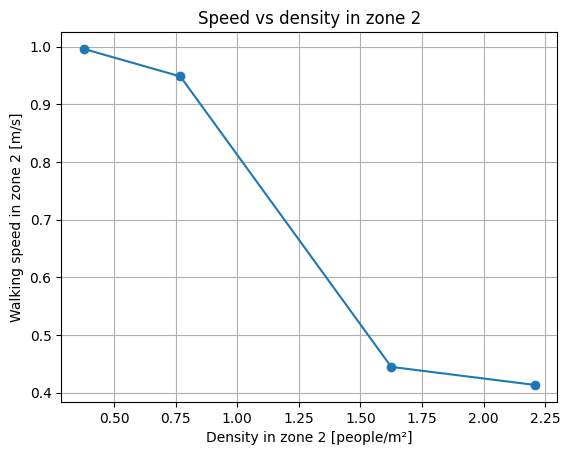

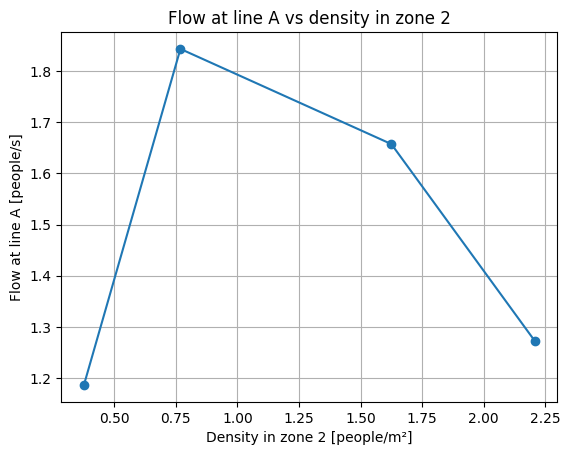

In [ ]:

plt.figure()
plt.plot(results_df["density_zone2"], results_df["speed_zone2"], marker="o")
plt.xlabel("Density in zone 2 [people/m²]")
plt.ylabel("Walking speed in zone 2 [m/s]")
plt.title("Speed vs density in zone 2")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(results_df["density_zone2"], results_df["flow_A"], marker="o")
plt.xlabel("Density in zone 2 [people/m²]")
plt.ylabel("Flow at line A [people/s]")
plt.title("Flow at line A vs density in zone 2")
plt.grid(True)
plt.show()

The results reproduce the expected qualitative behavior of the pedestrian flow: decreasing speed with increasing density. For the flow density relationship:
- If the density is too low -> few people -> low flow
- At medium density -> more people but speed is still unaffected -> increase in flow
- At high density -> speed drops -> flow decreases.

## Cleanup

In [13]:
result.cleanup()
print("Done.")

Done.
